In [1]:
from pathlib import Path

import cot_reports as cot

from analysis.data_loader import DataLoader
from analysis.yahoo_finance_downloader import YahooFinanceDownloader
from analysis.data_processor import DataProcessor
from analysis.plotter import Plotter
from analysis.constants import currencies_futures

asset = "USD"
ticker = currencies_futures[asset]["ticker"]
year = 2025
# Define the path relative to the current file
filename = f"{year}FinComYY.txt"
data_folder = Path("data")
plot_folder = Path("plots")
data_path = data_folder / filename


In [2]:
# Download the COT data if the file does not exist
# check if in data folder exist a file called f{year}FinComYY.txt
if not data_path.exists():
    cot.cot_year(year=year, cot_report_type="traders_in_financial_futures_futopt")
else:
    print(f"File {data_path} already exists")


File data/2025FinComYY.txt already exists


In [3]:
# Download the price data if the file does not exist

# Load and preprocess COT data
data_loader = DataLoader(filename=data_path)
df_asset = data_loader.load_and_preprocess(currencies_futures, asset)


# Download and preprocess price data
yahoo_downloader = YahooFinanceDownloader(asset, ticker, year)
price_data = yahoo_downloader.load_and_preprocess()

# Process data
data_processor = DataProcessor(df_asset, price_data)
merged_data = data_processor.merge_data()


The file /mnt/c/Users/x/Documents/GitHub/cot_reports/data/USD_2025_daily_data.csv already exists.


In [4]:
df_asset

,AM_L,AM_S,Ch_AM_L,Ch_AM_S,AM_Net
Date,,,,,
2025-01-07,22117.0,278.0,2492.0,58.0,21839.0
2025-01-14,22451.0,205.0,334.0,-73.0,22246.0
2025-01-21,21935.0,667.0,-516.0,462.0,21268.0
2025-01-28,18866.0,570.0,-3069.0,-97.0,18296.0
2025-02-04,18334.0,527.0,-532.0,-43.0,17807.0


In [5]:
df_asset.head()

,AM_L,AM_S,Ch_AM_L,Ch_AM_S,AM_Net
Date,,,,,
2025-01-07,22117.0,278.0,2492.0,58.0,21839.0
2025-01-14,22451.0,205.0,334.0,-73.0,22246.0
2025-01-21,21935.0,667.0,-516.0,462.0,21268.0
2025-01-28,18866.0,570.0,-3069.0,-97.0,18296.0
2025-02-04,18334.0,527.0,-532.0,-43.0,17807.0


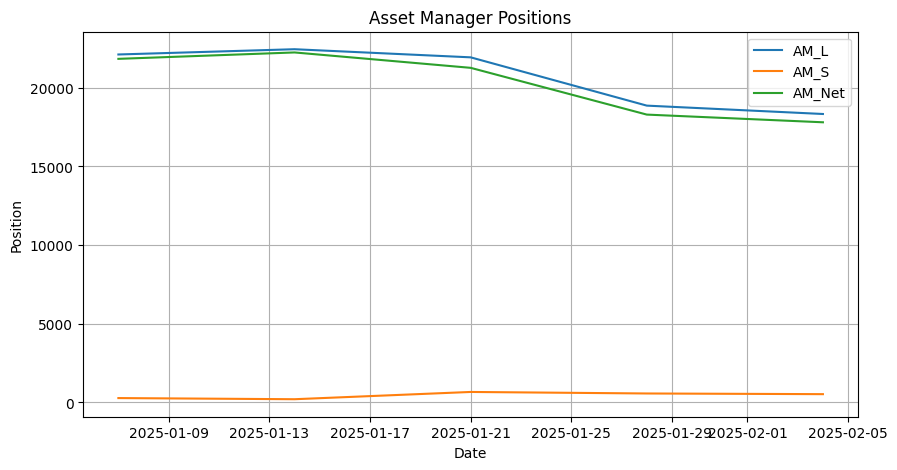

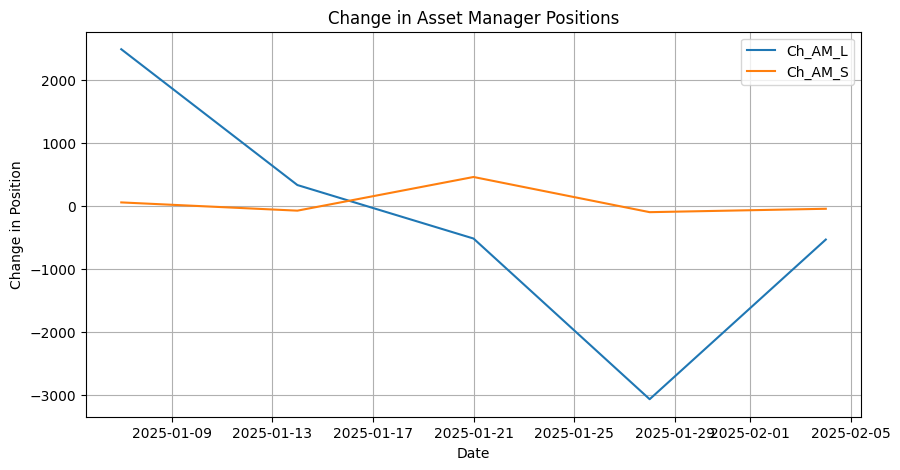

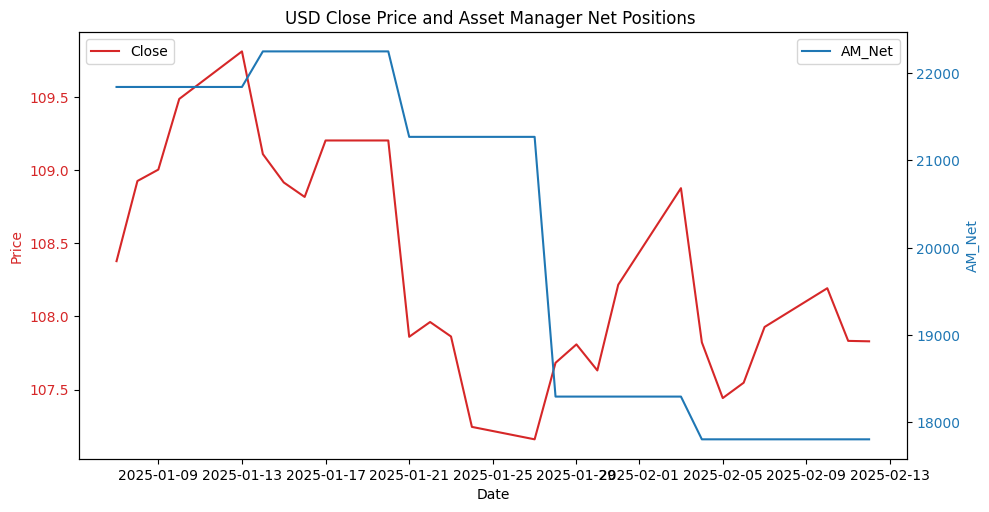

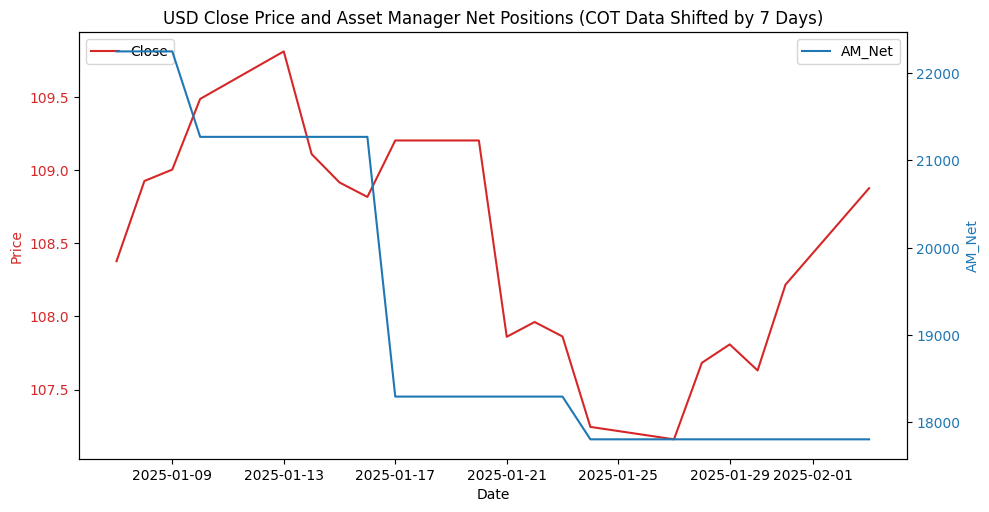

In [ ]:
# Plot COT data
plotter = Plotter(plot_folder, asset)
plotter.plot_asset_manager_positions(df_asset, show_plot=True)

# Plot price data and cot
plotter.plot_price_and_cot(merged_data, show_plot=True)

# Shift COT data and plot
if False:
    shifted_data = data_processor.shift_cot_data(shift_days=7)
    plotter.plot_price_and_cot(shifted_data, title="(COT Data Shifted by 7 Days)", show_plot=True)
